# 01 - What is a Neural Network?

**Goal:** Understand the basic building blocks before writing any ML code.

---

## The Simple Analogy

A neural network is just a **function** that:
1. Takes some input (image, text, numbers)
2. Does math operations
3. Produces an output (classification, prediction, segmentation mask)

The "magic" is that this function has **parameters** (weights) that are learned from data, not programmed by hand.

```
Traditional programming:  Rules + Data → Output
Machine learning:         Data + Output → Rules (learned weights)
```

## The Neuron (Perceptron)

The basic unit. It does this:

```
inputs: [x1, x2, x3]
weights: [w1, w2, w3]
bias: b

output = activation(x1*w1 + x2*w2 + x3*w3 + b)
```

That's it. Multiply inputs by weights, sum them, add bias, apply activation function.

The **activation function** adds non-linearity (without it, stacking layers would be pointless - it would all collapse to one linear function).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A single neuron - it's just math
def neuron(inputs, weights, bias):
    """One neuron: weighted sum + bias"""
    return np.dot(inputs, weights) + bias

def relu(x):
    """ReLU activation: if negative -> 0, else keep value"""
    return np.maximum(0, x)

def sigmoid(x):
    """Sigmoid activation: squash to 0-1 range"""
    return 1 / (1 + np.exp(-x))

# Example
inputs = np.array([1.0, 2.0, 3.0])
weights = np.array([0.5, -0.3, 0.8])  # These are LEARNED during training
bias = 0.1

raw_output = neuron(inputs, weights, bias)
activated_output = relu(raw_output)

print(f"Inputs: {inputs}")
print(f"Weights: {weights}")
print(f"Raw output (before activation): {raw_output:.2f}")
print(f"After ReLU activation: {activated_output:.2f}")

Inputs: [1. 2. 3.]
Weights: [ 0.5 -0.3  0.8]
Raw output (before activation): 2.40
After ReLU activation: 2.40


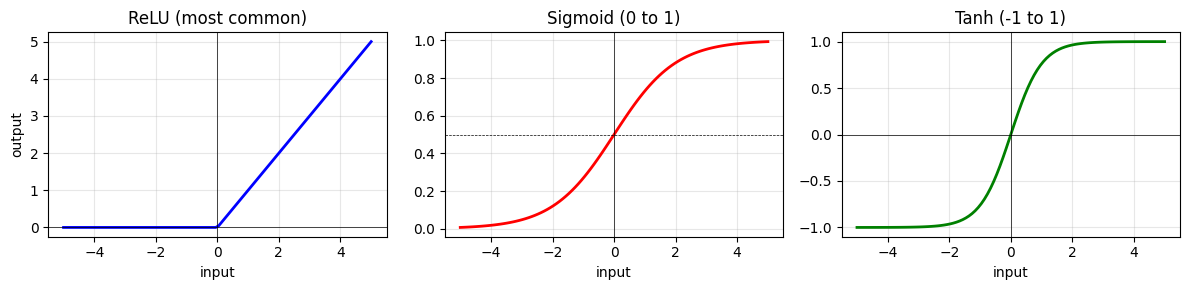

In [2]:
# Visualize activation functions
x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# ReLU
axes[0].plot(x, relu(x), 'b-', linewidth=2)
axes[0].set_title('ReLU (most common)')
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('input')
axes[0].set_ylabel('output')
axes[0].grid(True, alpha=0.3)

# Sigmoid
axes[1].plot(x, sigmoid(x), 'r-', linewidth=2)
axes[1].set_title('Sigmoid (0 to 1)')
axes[1].axhline(y=0.5, color='k', linestyle='--', linewidth=0.5)
axes[1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('input')
axes[1].grid(True, alpha=0.3)

# Tanh
axes[2].plot(x, np.tanh(x), 'g-', linewidth=2)
axes[2].set_title('Tanh (-1 to 1)')
axes[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[2].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[2].set_xlabel('input')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Activation Functions: Real-World Intuition

**ReLU as a one-way valve:**
- Positive signal → flows through unchanged
- Negative signal → blocked completely (becomes 0)
- The network only propagates "evidence for" something

**What's used in practice:**

| Where | Function | Why |
|-------|----------|-----|
| Hidden layers | ReLU (or GELU, SiLU) | Fast, no vanishing gradient |
| Binary output (yes/no) | Sigmoid | Need probability 0-1 |
| Multi-class output | Softmax | Probabilities that sum to 1 |

## Layers = Many Neurons Together

A **layer** is just multiple neurons processing the same input in parallel.

```
Input (3 values) → Layer with 4 neurons → Output (4 values)

Each neuron in the layer:
- Has its own weights (3 weights, one per input)
- Has its own bias
- Produces one output value
```

In matrix form: `output = activation(input @ weights + bias)`

This is why GPUs are good at this - it's all matrix multiplication.

In [2]:
# A layer = matrix of weights
def layer(inputs, weights, bias):
    """One layer: matrix multiplication + bias + activation"""
    return relu(np.dot(inputs, weights) + bias)

# 3 inputs -> 4 neurons -> 4 outputs
inputs = np.array([1.0, 2.0, 3.0])
weights = np.random.randn(3, 4) * 0.5  # 3 inputs, 4 neurons = 3x4 matrix
bias = np.zeros(4)

output = layer(inputs, weights, bias)

print(f"Input shape: {inputs.shape}")
print(f"Weights shape: {weights.shape}")
print(f"Output shape: {output.shape}")
print(f"Output values: {output}")

Input shape: (3,)
Weights shape: (3, 4)
Output shape: (4,)
Output values: [0.42692919 0.         0.         0.        ]


## Neural Network = Stacked Layers

A neural network is just layers stacked together:

```
Input (784 pixels)
    ↓
Layer 1: 784 → 128 neurons
    ↓
Layer 2: 128 → 64 neurons  
    ↓
Layer 3: 64 → 10 neurons (output: 10 digit classes)
    ↓
Output (10 probabilities)
```

Each layer transforms the data. Early layers learn simple features (edges, colors), later layers combine them into complex concepts (faces, objects).

In [6]:
# A simple neural network from scratch
class SimpleNetwork:
    def __init__(self):
        # Random initial weights (in practice, these are LEARNED)
        self.w1 = np.random.randn(784, 128) * 0.01
        self.b1 = np.zeros(128)
        self.w2 = np.random.randn(128, 64) * 0.01
        self.b2 = np.zeros(64)
        self.w3 = np.random.randn(64, 10) * 0.01
        self.b3 = np.zeros(10)
    
    def forward(self, x):
        """Forward pass: input → output"""
        # Layer 1
        x = relu(np.dot(x, self.w1) + self.b1)
        # Layer 2
        x = relu(np.dot(x, self.w2) + self.b2)
        # Layer 3 (output layer, no activation - will apply softmax later)
        x = np.dot(x, self.w3) + self.b3
        return x

# Create network
net = SimpleNetwork()

# Fake image input (28x28 = 784 pixels, flattened)
fake_image = np.random.randn(784)

# Forward pass
output = net.forward(fake_image)

print(f"Input: 784 pixels (28x28 image)")
print(f"Output: {output.shape[0]} values (one per digit class)")
print(f"Raw output: {output}")
print(f"Predicted digit: {np.argmax(output)} (random, network is untrained)")

Input: 784 pixels (28x28 image)
Output: 10 values (one per digit class)
Raw output: [-0.00096571 -0.00238716  0.00026704 -0.00034179 -0.00111996 -0.00072326
 -0.00172222  0.00150512 -0.00057664  0.00062665]
Predicted digit: 7 (random, network is untrained)


## Key Insight: What Gets Learned?

The **weights and biases** are the learnable parameters.

- A small network might have thousands of parameters
- GPT-4 has ~1.7 trillion parameters
- Your spine segmentation model (SwinUNETR) has ~60 million parameters

The architecture (how many layers, what type) is designed by humans.
The weights are learned from data.

```python
# This is what a .pth file contains - just the learned weights!
# Your production code loads them like this:
model.load_state_dict(torch.load('best_metric_model.pth'))
```

In [7]:
# Count parameters in our simple network
total_params = (
    784 * 128 + 128 +    # Layer 1: weights + biases
    128 * 64 + 64 +      # Layer 2
    64 * 10 + 10         # Layer 3
)

print(f"Our simple network: {total_params:,} parameters")
print(f"SwinUNETR (your production model): ~62,000,000 parameters")
print(f"GPT-4: ~1,700,000,000,000 parameters")

Our simple network: 109,386 parameters
SwinUNETR (your production model): ~62,000,000 parameters
GPT-4: ~1,700,000,000,000 parameters


## Summary

| Concept | What it is |
|---------|------------|
| Neuron | `output = activation(sum(inputs * weights) + bias)` |
| Layer | Many neurons in parallel (matrix multiplication) |
| Network | Stacked layers |
| Weights | Learnable parameters (what gets saved in .pth files) |
| Activation | Non-linear function (ReLU, sigmoid, etc.) |
| Forward pass | Input → through all layers → output |

**Next:** How do we actually LEARN those weights? → Training & Loss Functions

---

## Connection to Your Production Code

In `segmentation/src/inference_engine_v016.py`:

```python
# This creates the network architecture (empty weights)
model = SwinUNETR(
    img_size=[96, 96, 96],
    in_channels=1,
    out_channels=nb_classes,
    feature_size=24,
)

# This loads the LEARNED weights
model.load_state_dict(torch.load('best_metric_model.pth'))

# This runs the forward pass (input image → segmentation mask)
prediction = model(input_image)
```

The architecture is more complex (transformers, skip connections, 3D convolutions), but the principle is the same: input → layers → output.